# Using Foundation Models in TIAToolbox

Click to open in: \[[GitHub](https://github.com/TissueImageAnalytics/tiatoolbox/blob/develop/examples/11-import-foundation-models.ipynb)\]\[[Colab](https://colab.research.google.com/github/TissueImageAnalytics/tiatoolbox/blob/develop/examples/11-import-foundation-models.ipynb)\]



## About this notebook

This jupyter notebook can be run on any computer with a standard browser and no prior installation of any programming language is required. It can run remotely over the Internet, free of charge, thanks to Google Colaboratory. To connect with Colab, click on one of the two blue checkboxes above. Check that "colab" appears in the address bar. You can right-click on "Open in Colab" and select "Open in new tab" if the left click does not work for you. Familiarize yourself with the drop-down menus near the top of the window. You can edit the notebook during the session, for example substituting your own image files for the image files used in this demo. Experiment by changing the parameters of functions. It is not possible for an ordinary user to permanently change this version of the notebook on GitHub or Colab, so you cannot inadvertently mess it up. Use the notebook's File Menu if you wish to save your own (changed) notebook.

To run the notebook on any platform, except for Colab, set up your Python environment, as explained in the
[README](https://github.com/TIA-Lab/tiatoolbox/blob/master/README.md#install-python-package) file.



## About this demo

In this example, we demonstrate how to extract features from a pre-trained PyTorch foundation model using the PyTorch Image Models (`timm` module). This model operates outside of TIAToolbox, but we will utilize the WSI inference engines provided by TIAToolbox to achieve this.



## Setting up the environment

### TIAToolbox and dependencies installation

You can skip the following cell if 1) you are not using the Colab plaform or 2) you are using Colab and this is not your first run of the notebook in the current runtime session. If you nevertheless run the cell, you may get an error message, but no harm will be done. On Colab the cell installs `tiatoolbox`, and other prerequisite software. Harmless error messages should be ignored. Outside Colab , the notebook expects `tiatoolbox` to already be installed. (See the instructions in [README](https://github.com/TIA-Lab/tiatoolbox/blob/master/README.md#install-python-package).)

To use foundation models we have to ensure that we have specific [HuggingFace](https://huggingface.co/) libraries installed also.



In [ ]:
%%bash
apt-get -y install libopenjp2-7-dev libopenjp2-tools libpixman-1-dev | tail -n 1
pip install uv
uv pip install tiatoolbox | tail -n 1
echo "Installation is done."

**IMPORTANT**: When you run the cell above for the first time, while using Colab, you need to restart the session before proceeding further. Click on the box *Restart session* that appears immediately above this cell, or use the menu *Runtime→Restart session*. This loads the latest versions of prerequisite packages. The notebook can then be managed normally. For example, you can run subsequent cells one by one, or you can click on *Runtime→Run all* or *Runtime→after*.



### Importing related libraries

We will start by importing some libraries required to run this notebook.



In [ ]:
"""Import modules required to run the Jupyter notebook."""

import logging
import sys
import warnings
from pathlib import Path

import dask.array as da
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import umap
import zarr
from huggingface_hub import hf_hub_download, notebook_login

from tiatoolbox import logger
from tiatoolbox.models.engine.deep_feature_extractor import DeepFeatureExtractor
from tiatoolbox.models.engine.io_config import IOPatchPredictorConfig
from tiatoolbox.wsicore.wsireader import WSIReader

# Configure logging and warnings
if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

if "google.colab" in sys.modules:
    from google.colab import output

    output.enable_custom_widget_manager()
    logger.info("Custom widget manager enabled in Google Colab environment.")

# Configure matplotlib
mpl.rcParams["figure.dpi"] = 300  # for high resolution figure in notebook
mpl.rcParams["figure.facecolor"] = "white"  # To make sure text is visible in dark mode

### GPU or CPU runtime

Processes in this notebook can be accelerated by using a GPU. Therefore, whether you are running this notebook on your system or Colab, you need to check and specify appropriate [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) e.g., "cuda" or "cpu" whether you are using GPU or CPU. In Colab, you need to make sure that the runtime type is set to GPU in the *"Runtime→Change runtime type→Hardware accelerator"*. If you are *not* using GPU, consider changing the `device` flag to `cpu` value, otherwise, some errors will be raised when running the following cells.



In [3]:
device = "cuda"  # Choose appropriate device

### Removing leftovers from previous runs

This cell removes the directory `tmp` if it exists—a previous run may have created it. This cell can be skipped if you are running this notebook for the first time.



In [4]:
![ -d tmp ] && ( echo "deleting tmp directory"; rm -rf tmp )

deleting tmp directory


### Downloading the required files

We download, over the internet, a histology whole slide image of cancerous breast tissue samples to show how the feature extractor works. Download is needed once in each Colab session.

> In Colab, if you click the files icon (see below) in the vertical toolbar on the left hand side then you can see all the files which the code in this notebook can access. The data will appear here when it is downloaded.
>
> 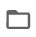



In [5]:
global_save_dir = "./tmp"
if not Path(global_save_dir).exists():
    Path(global_save_dir).mkdir(exist_ok=True)

# Downloading sample image tile
wsi_path = hf_hub_download(
    repo_id="TIACentre/TIAToolBox_Remote_Samples",
    filename="sample_wsis/TCGA-3L-AA1B-01Z-00-DX1.8923A151-A690-40B7-9E5A-FCBEDFC2394F.svs",
    repo_type="dataset",
    local_dir=global_save_dir,
)

sample_wsis/TCGA-3L-AA1B-01Z-00-DX1.8923(…):   0%|          | 0.00/1.23G [00:00<?, ?B/s]

## Feature extraction with foundation models

In this section, we extract deep features using foudnation models. These features could be used to train a downstream model. These models require access to HuggingFace, so please ensure that you have a University linked account if you are using this for research.

We then sign in to HuggingFace.



In [6]:
notebook_login()

Next, we create the model using pre-trained network architectures. For other models available in the `timm` library, such as computational pathology-specific foundation models, use `TimmBackbone` (e.g., `"EfficientNet"`, `"UNI"`, `"Prov-GigaPath"`, `"H-optimus-0"`). For standard CNN model architectures available in PyTorch (e.g., `"AlexNet"`, `"ResNet"`, `"DenseNet"`, `"Inception"`), use `CNNBackbone`.

In the example below, we use the `kaiko` model. However, this can be changed to other computational pathology-specific foundation models by modifying the `model` argument to `prov-gigapath` or `H-optimus-0`. When using foundation models, please ensure to cite the corresponding paper and follow the specific access requirements. Certain models require users to link their GitHub and HuggingFace accounts and have their model access request accepted, subject to certain conditions, such as for [UNI](https://huggingface.co/MahmoodLab/UNI) and [Prov-GigaPath](https://huggingface.co/prov-gigapath/prov-gigapath). Other models, such as [kaiko](https://huggingface.co/1aurent/vit_large_patch14_reg4_224.kaiko_ai_towards_large_pathology_fms) as used here, have no such requirements.

We also provide an `IOPatchPredictorConfig` specifying the input/output patch shape and resolution for processing and saving the output.

Finally, we use the `DeepFeatureExtractor` to extract these deep features, per patch, from the WSI. A mask is automatically generated to guide the patch extraction process and ignore the background.



In [ ]:
wsi_ioconfig = IOPatchPredictorConfig(
    input_resolutions=[{"units": "mpp", "resolution": 0.5}],
    patch_input_shape=[224, 224],
    stride_shape=[224, 224],
)

# create the feature extractor and run it on the WSI
extractor = DeepFeatureExtractor(
    model="kaiko",
    batch_size=32,
    num_workers=4,
)

out = extractor.run(
    images=[wsi_path],
    ioconfig=wsi_ioconfig,
    patch_mode=False,
    save_dir=Path(global_save_dir) / "wsi_features",
    device=device,
    output_type="zarr",
)

GPU is not compatible with torch.compile. Compatible GPUs include NVIDIA V100, A100, and H100. Speedup numbers may be lower than expected.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

Read: Scale > 1.This means that the desired resolution is higher than the WSI baseline (maximum encoded resolution). Interpolation of read regions may occur.


Inferring patches:   0%|          | 0/629 [00:00<?, ?it/s]

[########################################] | 100% Completed | 1.64 sms


## Post-processing and Visualization

These deep features could be used to train a downstream model. However, in this section, we will use `UMAP` reduction to visualize the features in RGB space to gain some intuition about what the features represent. Points labeled with similar colors should have similar features, allowing us to check if the features naturally separate into different tissue regions when we overlay the `UMAP` reduction on the WSI thumbnail.

The method returns a list of paths to its inputs and the processed outputs saved on disk. These paths can be used to load the results for further processing and visualization.



Text(0.5, 1.0, 'UMAP feature embedding')

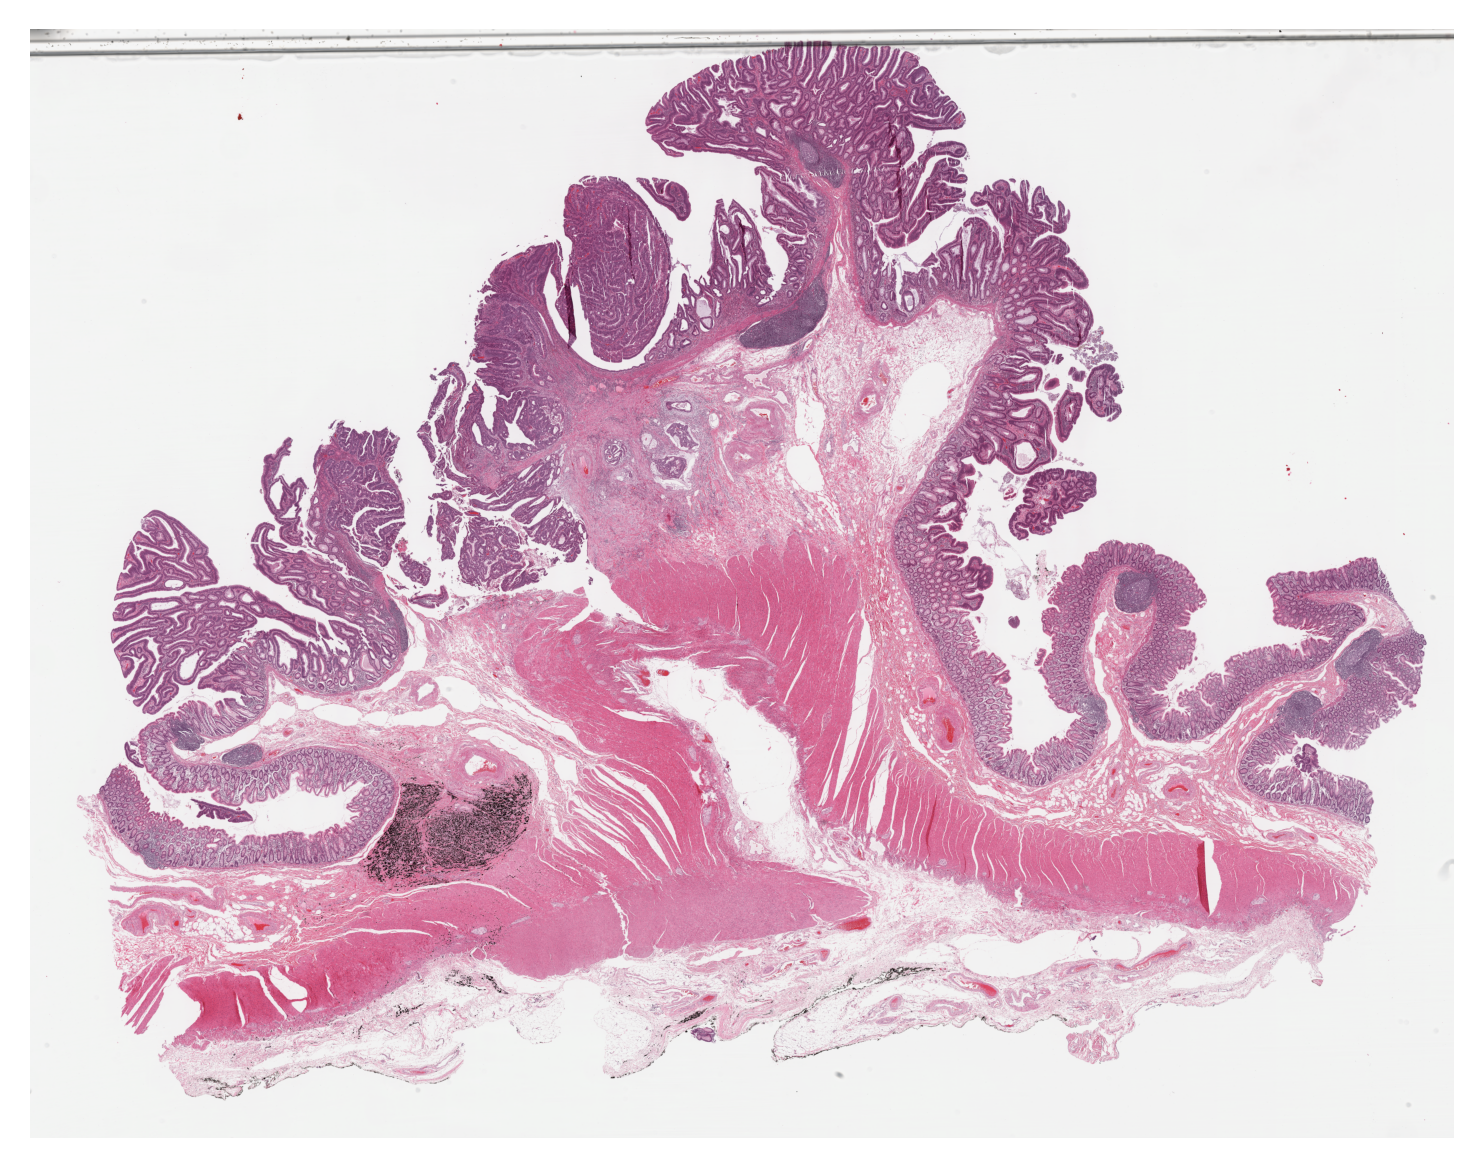

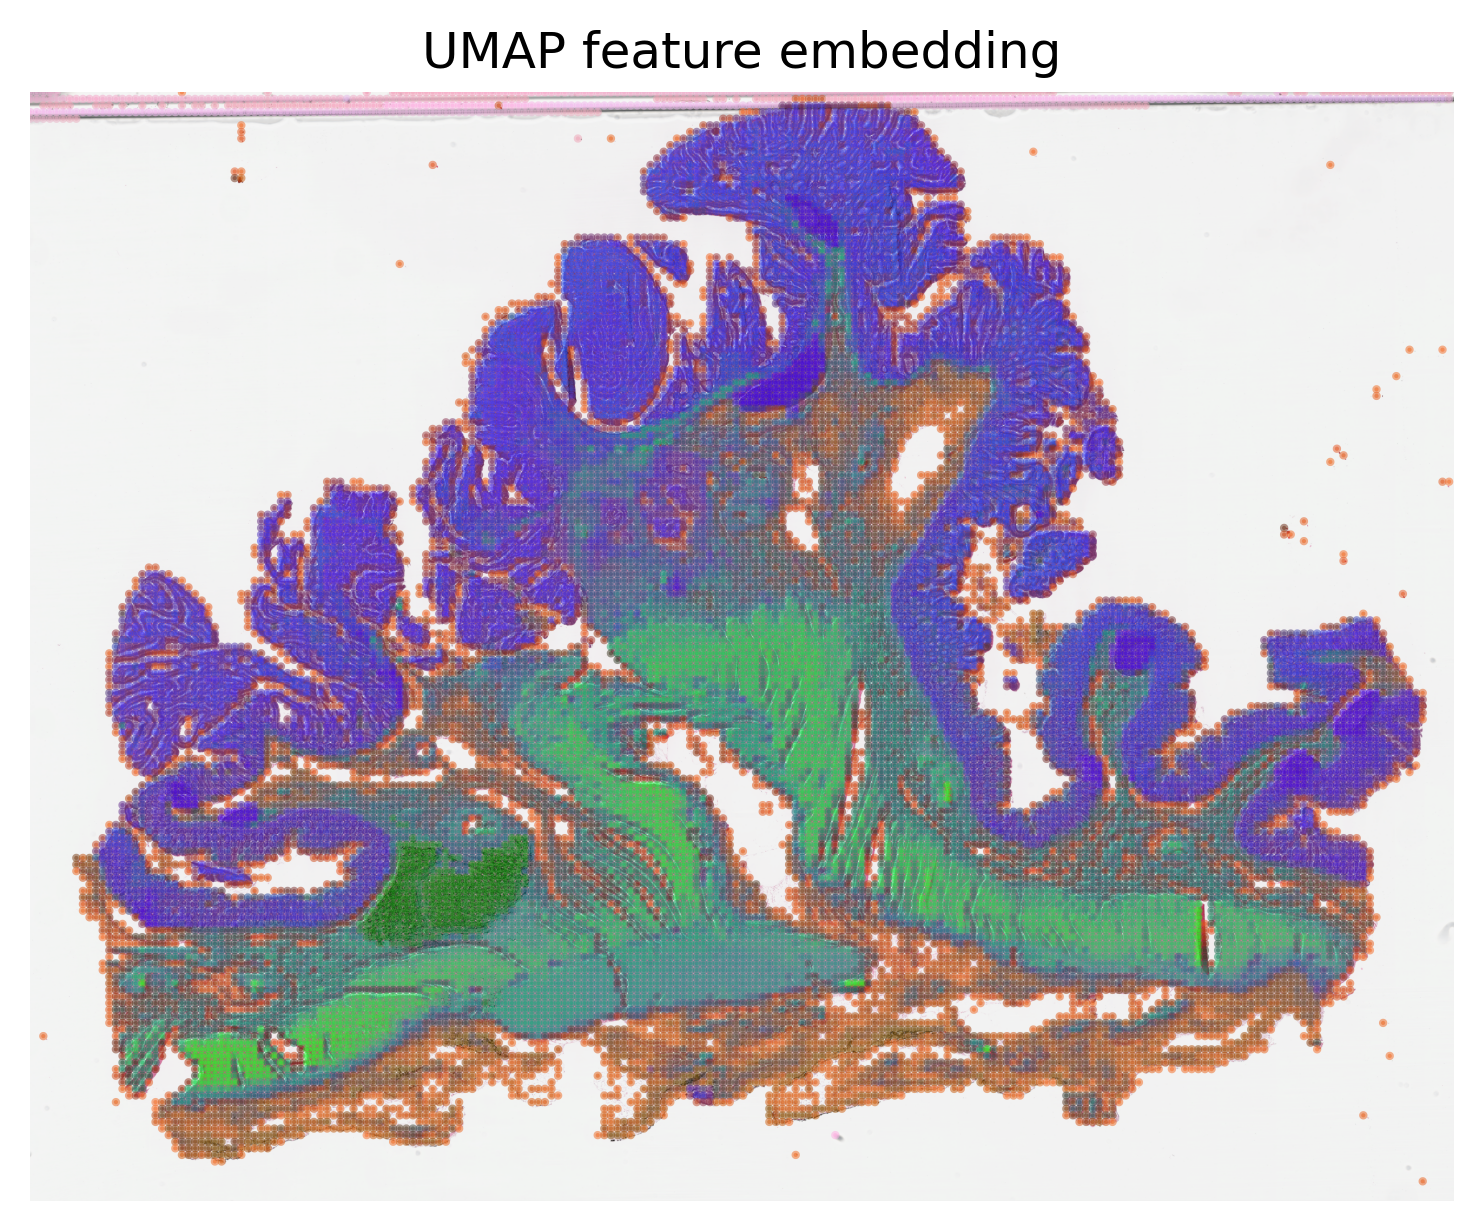

In [8]:
# First we define a function to calculate the umap reduction
def umap_reducer(x: np.ndarray, dims: int = 3, nns: int = 10) -> np.ndarray:
    """UMAP reduction of the input data."""
    reducer = umap.UMAP(
        n_neighbors=nns,
        n_components=dims,
        metric="manhattan",
        spread=0.5,
        random_state=2,
    )
    reduced = reducer.fit_transform(x)
    reduced -= reduced.min(axis=0)
    reduced /= reduced.max(axis=0)
    return reduced


# load the features output by our feature extractor
zarr_features = zarr.open(out[Path(wsi_path)])
pos = da.from_zarr(zarr_features["coordinates"])
feats = da.from_zarr(zarr_features["features"])
pos = pos / 8  # as we extracted at 0.5mpp, and we are overlaying on a thumbnail at 4mpp

# reduce the features into 3 dimensional (rgb) space
reduced = umap_reducer(feats)

overview_resolution = (
    4  # the resolution in which we desire to merge and visualize the patch predictions
)
# the unit of the `resolution` parameter. Can be "power", "level", "mpp", or "baseline"
overview_unit = "mpp"
wsi = WSIReader.open(wsi_path)
wsi_overview = wsi.slide_thumbnail(resolution=overview_resolution, units=overview_unit)
plt.figure(), plt.imshow(wsi_overview)
plt.axis("off")

# plot the feature map reduction
plt.figure()
plt.imshow(wsi_overview)
plt.scatter(pos[:, 0], pos[:, 1], c=reduced, s=1, alpha=0.5)
plt.axis("off")
plt.title("UMAP feature embedding")

We observe that the feature map from our feature encoder captures similar information about the tissue types in the WSI, as different tissue types appear in distinct colors. This serves as a good sanity check, confirming that our models are functioning as expected.

